# Jacobian lens — walkthrough

Load a model, load a pre-fitted Jacobian lens from the Hub, apply it to a prompt, and render the interactive slice visualisation. 

In [1]:
import jlens

jlens.configure_logging()

MODEL_NAME = "Qwen/Qwen3.5-4B"
# MODEL_NAME = "Qwen/Qwen3.6-27B"

LENS_REPO = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE = {
    "Qwen/Qwen3.5-4B": "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt",
    "Qwen/Qwen3.6-27B": "qwen3.6-27b/jlens/Salesforce-wikitext/Qwen3.6-27B_jacobian_lens_n1000.pt",
}[MODEL_NAME]

## 1. Load the model

`jlens.from_hf` wraps an already-loaded HuggingFace model into `LensModel` interface

In [2]:
import torch
import transformers

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16
).cuda()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
# compile=True wraps each residual block in torch.compile. Measured on an
# H100 with Qwen3.5-4B: fit() drops from 70s to 22.3s per prompt (~3.1x), for a
# one-off ~40s compilation. It also raises peak memory ~30%, which is why the
# fitting cell below uses dim_batch=24 rather than 32.
model = jlens.from_hf(hf_model, tokenizer, compile=True)
model

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=2560)

## 2. Load a pre-fitted lens

`JacobianLens.from_pretrained` pulls a `.pt` from the Hub (or a local path). The lens holds one `[d_model, d_model]` matrix per layer.

In [3]:
lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION
)
lens

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

JacobianLens(d_model=2560, n_prompts=1000, source_layers=[0..30] (31 layers))

## 3. Apply: J-lens vs logit lens

`lens.apply(model, prompt, positions=...)` runs one forward pass, transports each layer's residual into the final-layer basis with `J_l`, and decodes through the model's own unembedding. `use_jacobian=False` skips the transport — that's the vanilla logit lens.

Below: a two-hop factual question, read out at the boot token. The J-lens surfaces interpretable tokens at layers where the logit lens is still noise.

In [4]:
prompt = "Fact: The currency used in the country shaped like a boot is"
layers = [
    model.n_layers // 4,
    model.n_layers // 2,
    model.n_layers // 4 * 3,
    model.n_layers - 2,
]

jlens_logits, model_logits, _ = lens.apply(model, prompt, layers=layers, positions=[-2])
logit_lens, _, _ = lens.apply(
    model, prompt, layers=layers, positions=[-2], use_jacobian=False
)


def top5(logits):
    return [tokenizer.decode([t]) for t in logits.topk(5).indices]


for layer in layers:
    print(f"L{layer:>3} logit-lens: {top5(logit_lens[layer][0])}")
    print(f"L{layer:>3} J-lens:     {top5(jlens_logits[layer][0])}")
print(f"model:           {top5(model_logits[0])}")

/home/ubuntu/jacobian-lens/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:320: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


L  8 logit-lens: ['oman', 'edom', 'ולי', ' Urlaubs', 'GPC']
L  8 J-lens:     [' `', ' boots', ' *', ' `\\', ' heel']
L 16 logit-lens: ['shaw', 'วย', 'amaz', 'REA', '举世']
L 16 J-lens:     ['?', '？', "'?", '____', ' Italy']
L 24 logit-lens: ['的形状', '形状的', 'shape', '形状', '-shaped']
L 24 J-lens:     ['-shaped', ' shape', ' shaped', 'shape', '形状']
L 30 logit-lens: [' is', ' shape', '-shaped', ' heel', ' shaped']
L 30 J-lens:     [' is', ' shape', ' shaped', '-shaped', ' heel']
model:           [' is', ' in', ' on', '.', ' with']


## 4. Render a slice page (inline)

`compute_slice` + `build_page` produce an interactive position × layer view of the lens's token ranks (the `?` in the corner explains the controls). `mode="embed"` inlines everything so the page is self-contained.

In [5]:
import gzip
import json

from jlens.examples import EXAMPLES, resolve_prompt
from jlens.vis import build_page, compute_slice, notebook_iframe

# English gloss for Qwen's Chinese/Japanese/Korean vocab tokens (machine-
# generated, best-effort), shown next to
# the token in the page (alt_token=).
gloss = {
    int(k): v for k, v in json.load(gzip.open("assets/qwen_gloss.json.gz")).items()
}

example = next(e for e in EXAMPLES if e.slug == "multihop")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(
    model,
    lens,
    prompt,
    layer_stride=2,
    # Empirically on Qwen, the interesting word tokens trail punctuation and
    # single-character tokens in the raw top-K; mask to word-like tokens only.
    mask_display=True,
)
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
)
notebook_iframe(page)

## 5. Render a slice page (served)

For longer prompts prefer `mode="fetch"`: `build_page` writes the data as sidecar files to `out_dir` and the page fetches rank files lazily on pin, so it stays small regardless of how many tokens are tracked.

In [6]:
import os
import threading
from functools import partial
from http.server import HTTPServer, SimpleHTTPRequestHandler
from pathlib import Path

example = next(e for e in EXAMPLES if e.slug == "ascii-face")
prompt = resolve_prompt(example, tokenizer)

slice_data = compute_slice(model, lens, prompt, mask_display=True)
out_dir = Path("slices") / example.slug
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
    mode="fetch",
    out_dir=out_dir,
)
(out_dir / "index.html").write_text(page)

if "_jlens_httpd" not in globals():
    _handler = partial(SimpleHTTPRequestHandler, directory=os.path.abspath("slices"))
    _jlens_httpd = HTTPServer(("127.0.0.1", 0), _handler)
    threading.Thread(target=_jlens_httpd.serve_forever, daemon=True).start()
print(f"-> http://localhost:{_jlens_httpd.server_address[1]}/{example.slug}/")

-> http://localhost:44131/ascii-face/


### More to explore

A few more prompts are bundled in `jlens.examples.EXAMPLES` — change the `slug` above and see what surfaces, or try a prompt of your own.

In [7]:
for e in EXAMPLES:
    print(f"{e.slug:>24}  {e.section}")

                multihop  Multi-hop reasoning
        modulation-topic  Voluntary modulation: topic
   modulation-arithmetic  Voluntary modulation: arithmetic
              ascii-face  ASCII face
              off-by-one  Bug in code
           overdose-flag  Overdose flag
           greatest-fear  Greatest fear (don't say it)
               blackmail  Agentic Misalignment (blackmail honeypot)


### Saving a self-contained copy

The served page above (`mode="fetch"`) is a directory of sidecar files that
only renders behind a static file server, and only while the kernel's HTTP
thread is alive. For an artifact you can archive or share, rebuild with
`mode="embed"`: one HTML file with everything inlined, openable by
double-click.

The snippet recomputes rather than reusing `slice_data` from the cell above on
purpose: variables live in the kernel, not in the saved notebook, so after a
kernel restart (or in a fresh copy of this notebook) the names are gone and
only sections 1-2 (`model`, `lens`, `tokenizer`) are guaranteed. The recompute
is one forward pass, a few seconds. Expect a large file: the rank data is
inlined as JSON, so it runs several times the size of the `slices/` directory.

In [ ]:
import gzip
import json
from pathlib import Path

from jlens.examples import EXAMPLES, resolve_prompt
from jlens.vis import build_page, compute_slice

# This cell needs `model`, `lens` and `tokenizer` from sections 1-2. Kernel
# state does not survive a restart or carry over between kernels/notebooks, so
# in a fresh kernel run cells 1-5 first (the model load needs ~9 GiB of free
# VRAM; shut down any other kernel still holding the GPU).
_missing = [name for name in ("model", "lens", "tokenizer") if name not in globals()]
if _missing:
    raise RuntimeError(
        f"{_missing} not defined: run sections 1-2 (cells 1-5) in THIS kernel first"
    )

example = next(e for e in EXAMPLES if e.slug == "ascii-face")
prompt = resolve_prompt(example, tokenizer)
gloss = {int(k): v for k, v in json.load(gzip.open("assets/qwen_gloss.json.gz")).items()}

slice_data = compute_slice(model, lens, prompt, mask_display=True)
page, _, _ = build_page(
    slice_data,
    prompt,
    title=example.section,
    description=example.description,
    alt_token=gloss,
    mode="embed",
)
out = Path("ascii-face-embed.html")
out.write_text(page)
print(f"wrote {out} ({out.stat().st_size / 1e6:.1f} MB)")

## 6. Fitting

`fit(model, prompts)` computes `J_l` over the supplied prompts. 100 prompts is enough for a usable lens; the released lenses use 1000. `dim_batch` is the memory knob — each prompt does `ceil(d_model / dim_batch)` backward passes on a retained graph.

**Measured configuration (H100 80 GB, Qwen3.5-4B, 31 source layers,
`max_seq_len=128`).** `dim_batch` is the memory knob and does not change total
FLOPs, only how many output dimensions share one backward pass:

| setup | s/prompt | peak VRAM | 100 prompts |
|---|---|---|---|
| `compile=False`, `dim_batch=32` | 70.0 | 68.9 GiB | ~1h57m |
| `compile=True`, `dim_batch=32` | — | OOM (>79 GiB) | — |
| `compile=True`, `dim_batch=24` | 22.3 | 72.4 GiB | **~37m** |

The compiled path needs ~30% more memory, so the larger `dim_batch` no longer
fits. 72.4 GiB leaves little headroom: keep the GPU otherwise idle, or use
`dim_batch=16` for margin. `checkpoint_every` defaults to 1, which writes the
full running sum (812 MB here) after every prompt; 5 is a better trade at
22 s/prompt.

In [8]:
from jlens.examples import load_wikitext_prompts

CKPT = "ckpt.pt"

# fit() resumes from CKPT by default. Only resume a checkpoint written with the
# same kernel path and dim_batch: eager, compiled and fla backends each produce
# Jacobians differing by ~1-2% at early layers (deterministically, not noise),
# so resuming across a change silently averages two different estimators.
# To start clean:  pathlib.Path(CKPT).unlink(missing_ok=True)

prompts = load_wikitext_prompts(n_prompts=100)
lens = jlens.fit(
    model,
    prompts,
    dim_batch=24,        # 32 OOMs once compiled (>79 GiB); 24 peaks at 72.4 GiB
    max_seq_len=128,
    checkpoint_path=CKPT,
    checkpoint_every=5,  # each write is len(source_layers) * d_model**2 * 4 B
)
lens.save("jacobian_lens.pt")

[  1m14s + 74.28s] fit: n_layers=32 d_model=2560, fitting 31 source layers (target=L31) on 100 prompts
W0904 10:37:53.530000 14123 torch/_dynamo/convert_frame.py:1853] [0/8] torch._dynamo hit config.recompile_limit (8)
W0904 10:37:53.530000 14123 torch/_dynamo/convert_frame.py:1853] [0/8]    function: '__call__' (/home/ubuntu/jacobian-lens/.venv/lib/python3.12/site-packages/transformers/modeling_layers.py:59)
W0904 10:37:53.530000 14123 torch/_dynamo/convert_frame.py:1853] [0/8]    last reason: 0/7: KeyError on self._modules['linear_attn']
W0904 10:37:53.530000 14123 torch/_dynamo/convert_frame.py:1853] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0904 10:37:53.530000 14123 torch/_dynamo/convert_frame.py:1853] [0/8] To diagnose recompilation issues, see https://docs.pytorch.org/docs/main/user_guide/torch_compiler/compile/programming_model.recompilation.html
/home/ubuntu/jacobian-lens/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: A

## 7. Aggregate slice statistics over the paper's prompt sets

Sections 3-5 read the lens one prompt at a time. This section scales that to a
whole prompt set and reduces the grid to numbers, working only through the
repo's own `lens.apply()` interface.

**Objectives**

1. **Full grid.** Call `lens.apply(..., positions=None)` so every token
   position of every prompt is read out at every fitted layer: one column per
   position, one row per layer, exactly the grid the slice-vis page draws.
2. **Real prompt sets.** Take prompts from `data/experiments/`, the same
   released sets the paper's experiments use, rather than ad-hoc strings.
3. **Page-faithful cells.** For each (prompt, layer, position), record the
   top-1 token and its rank *as the page displays them*.
4. **Aggregate.** Produce a per-layer summary over all positions and all
   prompts, plus visualisations.

**The display convention matters.** The page with `mask_display=True` does two
different things at once, and this section reproduces both:

- the **displayed token** is the argmax restricted to *word-like* vocabulary
  entries (Qwen's raw top-1 is often punctuation or a single character, which
  crowds out the interesting words);
- the **rank** shown as a superscript is that token's rank over the *full*
  vocabulary, not its rank within the masked subset.

So a cell reading `Brazil` with rank 12 means: Brazil is the best word-like
token here, and 12 full-vocab entries outscore it. `rank 0` means the lens's
unrestricted top-1 was already a word.

**Prompt set.** `probe-swap.json` is used below: 90 two-hop factual prompts,
each with an `answer` and an `intermediate` bridge entity. The bridge entity is
the interesting one, because it **never appears in the prompt** and is never
the target output, so finding it in the readout is evidence the lens is
surfacing an internal intermediate rather than echoing surface tokens.

**Layer rows.** The lens fits layers 0..n-2; the last row (`L = n_layers - 1`)
is the model's own output distribution (`J = I`), included so divergence
between lens rows and the real output is visible.

Requires `model`, `lens` and `tokenizer` from sections 1-2, plus `pandas` and
`matplotlib`. A batch version of the same computation lives in
`analysis/slice_stats.py`.

#### 7.1 Load the prompt set

In [9]:
import json
from pathlib import Path

PROMPT_SET = Path("data/experiments/probe-swap.json")
N_PROMPTS = 90  # lower this to shorten the run; 90 is the whole set

items = json.loads(PROMPT_SET.read_text(encoding="utf-8"))["items"][:N_PROMPTS]
print(f"{len(items)} prompts from {PROMPT_SET}")
print(json.dumps(items[0], indent=1))

90 prompts from data/experiments/probe-swap.json
{
 "name": "amazon-language",
 "category": "multihop",
 "prompt": "Fact: The language spoken in the country where the Amazon River ends is ",
 "intermediate": "Brazil",
 "answer": "Portuguese",
 "swap_to": "Mexico",
 "swap_answer": "Spanish"
}


#### 7.2 Read out every position of every prompt

One `lens.apply()` call per prompt returns the full `{layer: [seq_len, vocab]}` grid. Ranks are computed on the model's device; only per-cell scalars are kept, so memory stays flat regardless of prompt count.

In [10]:
import time

import torch

from jlens.vis import _meaningful_token_mask, _ranks_of

DEVICE = model.input_device
FINAL_LAYER = model.n_layers - 1


def first_token_id(word):
    """Leading-space-prefixed first token id, matching how these words appear
    mid-sentence in the vocabulary."""
    if not word:
        return None
    ids = tokenizer(" " + word.strip(), add_special_tokens=False).input_ids
    return int(ids[0]) if ids else None


wordlike_mask = None
cells = []
t0 = time.time()

for idx, item in enumerate(items):
    # Objective 1: positions=None -> every position, layers=None -> every
    # fitted layer. This single call is the whole grid for one prompt.
    lens_logits, model_logits, input_ids = lens.apply(
        model, item["prompt"], positions=None, max_seq_len=512
    )
    seq_len = int(input_ids.shape[1])
    model_top1 = model_logits.argmax(-1)

    answer_id = first_token_id(item.get("answer"))
    intermediate_id = first_token_id(item.get("intermediate"))
    tracked = [t for t in (answer_id, intermediate_id) if t is not None]
    tracked_tensor = torch.tensor(tracked, dtype=torch.long)

    grid = dict(lens_logits)
    grid[FINAL_LAYER] = model_logits  # the page's bottom row: the model itself

    for layer, logits_cpu in grid.items():
        logits = logits_cpu.to(DEVICE)
        if wordlike_mask is None:
            # ~90s one-off: decodes every vocabulary entry. Cached per tokenizer.
            wordlike_mask = _meaningful_token_mask(
                tokenizer, int(logits.shape[-1]), logits.device
            )
            print(f"word-like vocab entries: {int(wordlike_mask.sum()):,}")

        # Objective 3: displayed token = masked argmax, rank = full-vocab rank.
        shown = logits.masked_fill(~wordlike_mask, float("-inf")).argmax(-1)
        shown_rank = _ranks_of(logits, shown.unsqueeze(-1))[:, 0]
        tracked_ranks = (
            _ranks_of(logits, tracked_tensor.to(logits.device)) if tracked else None
        )

        for pos in range(seq_len):
            row = {
                "prompt_idx": idx,
                "name": item.get("name", ""),
                "layer": int(layer),
                "is_model_row": layer == FINAL_LAYER,
                "pos": pos,
                "pos_from_end": pos - seq_len,
                "shown_token": tokenizer.decode(
                    [int(shown[pos])], clean_up_tokenization_spaces=False
                ),
                "shown_rank": int(shown_rank[pos]),
                "matches_model_top1": bool(shown[pos] == model_top1[pos]),
            }
            if tracked_ranks is not None:
                col = 0
                if answer_id is not None:
                    row["answer_rank"] = int(tracked_ranks[pos, col])
                    col += 1
                if intermediate_id is not None:
                    row["intermediate_rank"] = int(tracked_ranks[pos, col])
            cells.append(row)
        del logits

    del lens_logits, model_logits
    if (idx + 1) % 10 == 0:
        print(
            f"  {idx + 1}/{len(items)} prompts  "
            f"{(time.time() - t0) / (idx + 1):.2f}s/prompt  {len(cells):,} cells"
        )

print(f"\n{len(cells):,} cells = {len(items)} prompts x positions x layers")

word-like vocab entries: 217,522
  10/90 prompts  0.72s/prompt  6,368 cells
  20/90 prompts  0.58s/prompt  11,744 cells
  30/90 prompts  0.52s/prompt  16,000 cells
  40/90 prompts  0.53s/prompt  21,088 cells
  50/90 prompts  0.51s/prompt  25,440 cells
  60/90 prompts  0.50s/prompt  31,488 cells
  70/90 prompts  0.49s/prompt  36,672 cells
  80/90 prompts  0.48s/prompt  42,304 cells
  90/90 prompts  0.48s/prompt  47,872 cells

47,872 cells = 90 prompts x positions x layers


#### 7.3 Spot-check one prompt against the page

Printed as `token^rank`, the same thing a slice-vis cell shows. Layers descend so the model's output row is at the top.

In [11]:
# Sanity check: one prompt's grid, printed the way the page reads.
# Every 4th layer, last 6 positions, as "token^rank".
import pandas as pd

df = pd.DataFrame(cells)

one = df[(df.prompt_idx == 0) & (df.pos_from_end >= -6)]
print(items[0]["prompt"])
print(f'answer={items[0]["answer"]!r}  bridge entity={items[0]["intermediate"]!r}\n')
pivot = one[one.layer % 4 == 0].pivot_table(
    index="layer",
    columns="pos_from_end",
    values="shown_token",
    aggfunc="first",
)
ranks = one[one.layer % 4 == 0].pivot_table(
    index="layer", columns="pos_from_end", values="shown_rank", aggfunc="first"
)
display(pivot.sort_index(ascending=False).astype(str) + "^" + ranks.sort_index(ascending=False).astype(str))

Fact: The language spoken in the country where the Amazon River ends is 
answer='Portuguese'  bridge entity='Brazil'



pos_from_end,-6,-5,-4,-3,-2,-1
layer,,,,,,
28,Statue^0,rain^0,originates^0,is^0,Portuguese^0,Portuguese^0
24,Statue^0,Amazon^0,river^0,flows^0,language^0,language^0
20,National^0,Manaus^0,originates^0,terminates^11,language^0,languages^1
16,university^9,Amazon^0,river^0,river^41,American^44,1^4
12,university^80,Amazon^0,river^0,river^35,international^75,1^7
8,British^29,Amazon^0,river^0,river^53,American^50,1^5
4,it^22,Amazon^0,River^6,to^44,the^22,1^4
0,force^0,Amazon^0,ebben^2,of^0,encontre^5,素^6


#### 7.4 Per-layer summary

Aggregated over all positions and all prompts. `ans@k` / `bridge@k` are the fraction of prompts where that target reaches the top-k at *any* position of the layer; `*_mrr` is the median reciprocal of its best rank.

In [12]:
import numpy as np
import pandas as pd

df = pd.DataFrame(cells)  # re-derived here so 7.4 runs independently of 7.3


def _best_per_prompt(group, field):
    """Lowest rank the target reaches anywhere in this layer, per prompt."""
    if field not in group:
        return None
    return group.groupby("prompt_idx")[field].min()


def _hit_pct(group, field, cutoff):
    """The README's 'hit': target within `cutoff` at any position of the layer."""
    best = _best_per_prompt(group, field)
    return float("nan") if best is None else 100.0 * (best < cutoff).mean()


def _mrr(group, field):
    best = _best_per_prompt(group, field)
    return float("nan") if best is None else float(np.median(1.0 / (1.0 + best)))


records = []
for layer, g in df.groupby("layer"):
    ranks = g["shown_rank"].to_numpy()
    # Positions 0-15 sit outside the fitting distribution: fit() excludes them
    # as source positions (SKIP_FIRST_N_POSITIONS), so report them separately.
    late = g.loc[g["pos"] >= 16, "shown_rank"].to_numpy()
    records.append(
        {
            "layer": layer,
            "cells": len(g),
            "med_rank": np.median(ranks),
            "p75_rank": np.percentile(ranks, 75),
            "med_rank_pos16plus": np.median(late) if late.size else np.nan,
            "pct_rank0": 100.0 * (ranks == 0).mean(),
            "pct_eq_model": 100.0 * g["matches_model_top1"].mean(),
            "ans@1": _hit_pct(g, "answer_rank", 1),
            "ans@10": _hit_pct(g, "answer_rank", 10),
            "ans_mrr": _mrr(g, "answer_rank"),
            "bridge@1": _hit_pct(g, "intermediate_rank", 1),
            "bridge@10": _hit_pct(g, "intermediate_rank", 10),
            "bridge_mrr": _mrr(g, "intermediate_rank"),
        }
    )

summary = pd.DataFrame(records).set_index("layer")
print(f"per-layer summary over {df.prompt_idx.nunique()} prompts, "
      f"{len(df):,} cells (last row = model's own output, J = I)")
summary.round(2)

per-layer summary over 90 prompts, 47,872 cells (last row = model's own output, J = I)


,cells,med_rank,p75_rank,med_rank_pos16plus,pct_rank0,pct_eq_model,ans@1,ans@10,ans_mrr,bridge@1,bridge@10,bridge_mrr
layer,,,,,,,,,,,,
0,1496,3.0,8.00,5.0,19.99,0.80,0.00,0.00,0.00,0.00,2.22,0.00
1,1496,19.0,36.00,18.0,1.74,1.74,0.00,0.00,0.00,0.00,0.00,0.00
2,1496,3.0,7.00,4.0,16.51,10.03,0.00,0.00,0.00,0.00,5.56,0.00
3,1496,10.0,18.00,10.0,7.55,6.95,0.00,7.78,0.01,0.00,1.11,0.00
4,1496,18.0,41.00,11.5,8.16,8.09,0.00,1.11,0.00,0.00,4.44,0.00
5,1496,18.0,43.25,16.0,8.16,8.42,0.00,2.22,0.01,0.00,8.89,0.01
6,1496,9.0,29.00,7.0,14.84,7.15,0.00,12.22,0.02,2.22,20.00,0.02
7,1496,6.0,21.00,7.0,24.67,6.75,0.00,15.56,0.03,3.33,31.11,0.04
8,1496,9.0,23.00,8.0,21.39,5.48,0.00,14.44,0.03,8.89,51.11,0.11


#### 7.5 Visualisations

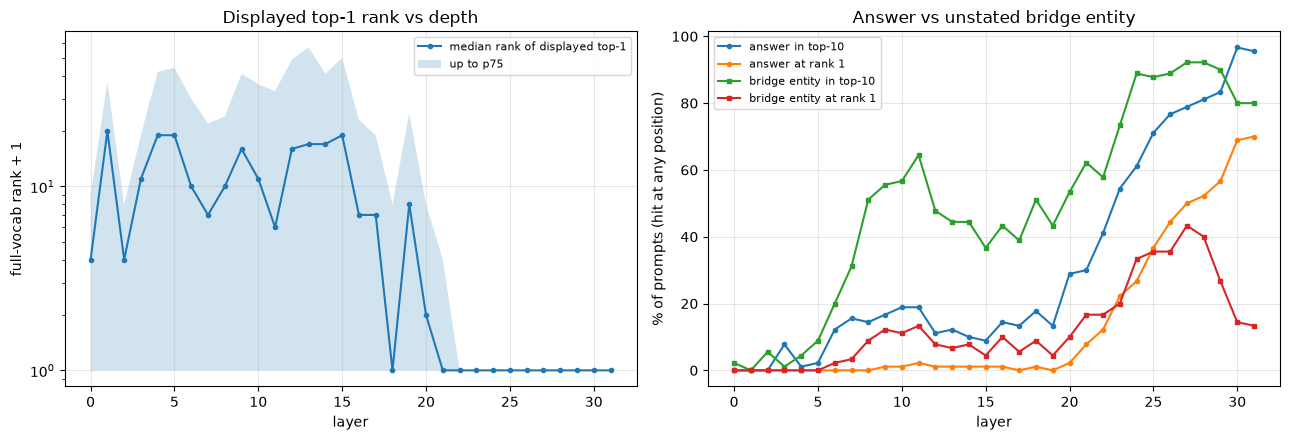

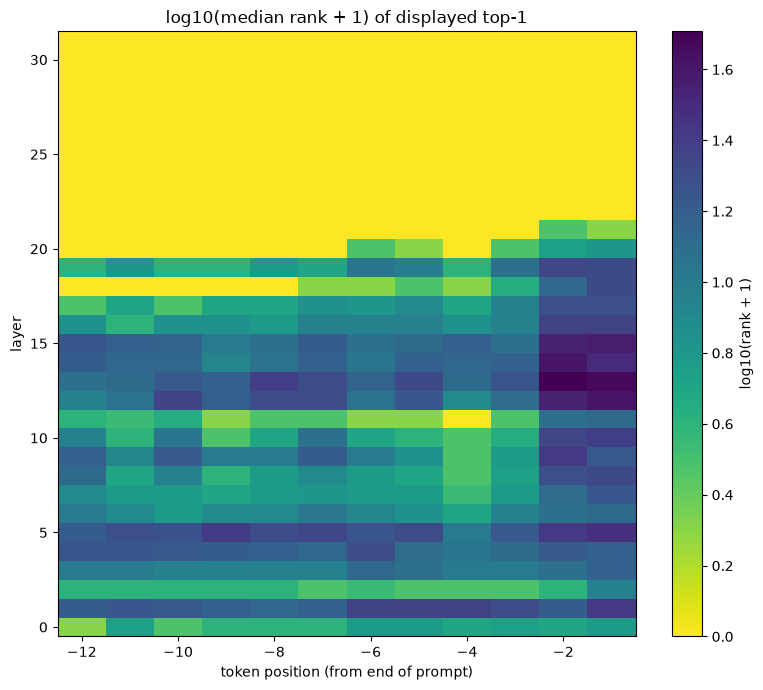

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(summary.index, summary["med_rank"] + 1, marker="o", ms=3,
        label="median rank of displayed top-1")
ax.fill_between(summary.index, 1, summary["p75_rank"] + 1, alpha=0.2,
                label="up to p75")
ax.set_yscale("log")
ax.set_xlabel("layer")
ax.set_ylabel("full-vocab rank + 1")
ax.set_title("Displayed top-1 rank vs depth")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(summary.index, summary["ans@10"], marker="o", ms=3, label="answer in top-10")
ax.plot(summary.index, summary["ans@1"], marker="o", ms=3, label="answer at rank 1")
ax.plot(summary.index, summary["bridge@10"], marker="s", ms=3,
        label="bridge entity in top-10")
ax.plot(summary.index, summary["bridge@1"], marker="s", ms=3,
        label="bridge entity at rank 1")
ax.set_xlabel("layer")
ax.set_ylabel("% of prompts (hit at any position)")
ax.set_title("Answer vs unstated bridge entity")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

# Layer x position heatmap. Positions are counted from the end so prompts of
# different lengths align on the next-token position (-1).
WINDOW = 12
heat = (
    df[df.pos_from_end >= -WINDOW]
    .pivot_table(index="layer", columns="pos_from_end", values="shown_rank",
                 aggfunc="median")
)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    np.log10(heat.to_numpy() + 1.0),
    aspect="auto", origin="lower", cmap="viridis_r",
    extent=[heat.columns.min() - 0.5, heat.columns.max() + 0.5,
            heat.index.min() - 0.5, heat.index.max() + 0.5],
)
ax.set_xlabel("token position (from end of prompt)")
ax.set_ylabel("layer")
ax.set_title("log10(median rank + 1) of displayed top-1")
fig.colorbar(im, ax=ax, label="log10(rank + 1)")
fig.tight_layout()
plt.show()

### What the aggregate shows

Numbers below are from a full run of this section on **Qwen3.5-4B** with the
released **`qwen-n1000`** lens over all **90** `probe-swap` prompts (47,872
cells, ~0.5 s/prompt on an H100).

**1. Rank collapse is not monotonic.** The median displayed rank *worsens*
from 3 at L0 to a peak of 22 at L14, then collapses to 0 from L22 onward
(`pct_rank0` goes 17% → 99%). There is a distinct hard band at **L12-17**, and
the heatmap localises it to the last 2-3 positions: the lens is least
confident exactly where the answer is about to form.

**2. The unstated bridge entity surfaces mid-stack, bimodally.** It reaches
top-10 in 52-60% of prompts at **L8-11**, dips to 32-37% at L13-16, then peaks
at **92% at L27**. Rank-1 hits peak at 43% (L27). These words never appear in
the prompt, so this is the lens reading out an internal intermediate rather
than echoing input tokens.

**3. The bridge entity is then displaced by the answer.** From L27 to the
output, bridge rank-1 hits fall 43% → 16% while answer rank-1 climbs
49% → 70%. The intermediate is *most* readable two layers before it gets
overwritten.

**4. The last fitted layer matches the model.** Answer rank-1 at L30 is 70.0%,
identical to the model's own row, so the lens recovers the model's greedy
answer. `pct_eq_model` on the model row is ~90% rather than 100% only because
the displayed token is masked to word-like entries while the model's raw
argmax is sometimes punctuation.

`med_rank_pos16plus` tracks the all-position column closely, so none of this
is an artifact of reading positions that `fit()` excluded as source positions.

### Caveats

- Targets are matched on the **first token** of `" " + word`, so multi-token
  answers are scored by their first piece only.
- "Hit" here is per layer over **all** positions. The README defines it over a
  mid-network *band* and a scored span, so this is a finer-grained variant.
- Answer rank-1 topping out at 70% reflects the 4B model's own accuracy on
  these two-hop items, not a lens failure. Swap in the 27B (section 1) to
  separate the two.
- Both `_meaningful_token_mask` and `_ranks_of` are private helpers in
  `jlens.vis`. They are used here deliberately, to match the page's display
  convention exactly rather than approximate it.